# Importación de librerías

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency

# Carga del dataset y exploración inicial

In [67]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "agaricus-lepiota.data"
df = pd.read_csv(data_path)
df.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [68]:
columns = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]

df.columns = columns

Odor (olor) → significados

a → almendra (almond)
l → anís (anise)
c → creosota (creosote)
y → a pescado (fishy)
f → fétido / desagradable (foul)
m → mohoso (musty)
n → sin olor (none)
p → picante / penetrante (pungent)
s → especiado (spicy)

In [69]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [70]:
df.shape

(8123, 23)

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8123 entries, 0 to 8122
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8123 non-null   str  
 1   cap-shape                 8123 non-null   str  
 2   cap-surface               8123 non-null   str  
 3   cap-color                 8123 non-null   str  
 4   bruises                   8123 non-null   str  
 5   odor                      8123 non-null   str  
 6   gill-attachment           8123 non-null   str  
 7   gill-spacing              8123 non-null   str  
 8   gill-size                 8123 non-null   str  
 9   gill-color                8123 non-null   str  
 10  stalk-shape               8123 non-null   str  
 11  stalk-root                8123 non-null   str  
 12  stalk-surface-above-ring  8123 non-null   str  
 13  stalk-surface-below-ring  8123 non-null   str  
 14  stalk-color-above-ring    8123 non-null   str  
 15

In [72]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123,...,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3655,3244,2283,4748,3528,7913,6811,5612,1728,...,4935,4463,4383,8123,7923,7487,3967,2388,4040,3148


In [73]:
(df == "?").sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [74]:
df = df.replace("?", np.nan)

In [75]:
df.isnull().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [76]:
df = df.drop(columns=["stalk-root"])

In [77]:
df.duplicated().sum()

np.int64(0)

e = comestibles y p=venenosos

In [78]:
# Buscar columnas con un solo valor único
columnas_inutiles = [col for col in df.columns if df[col].nunique() == 1]
print(f"Columnas que no aportan información: {columnas_inutiles}")
# 'veil-type' tiene un solo valor ('p'). Hay que eliminarla.
df = df.drop(columns=columnas_inutiles)

Columnas que no aportan información: ['veil-type']


El "Filtro de Varianza Cero" (Eliminar columnas inútiles)
Si una columna contiene el mismo valor para todos los registros, no ayuda al modelo a clasificar y solo añade ruido.

In [79]:
df["class"].value_counts()

class
e    4208
p    3915
Name: count, dtype: int64

# ANALISIS EXPLORATORIO DE DATOS. EDA

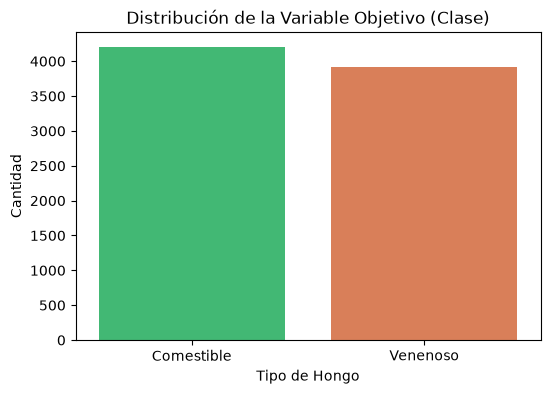

class
Comestible    51.803521
Venenoso      48.196479
Name: proportion, dtype: float64


In [80]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette={'e': '#2ecc71', 'p': '#e74'})
plt.title('Distribución de la Variable Objetivo (Clase)')
plt.xlabel('Tipo de Hongo')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Comestible', 'Venenoso']) # Set custom x-axis labels
plt.show()
# Print value counts with descriptive names
class_counts = df['class'].value_counts(normalize=True) * 100
print(class_counts.rename(index={'e': 'Comestible', 'p': 'Venenoso'}))

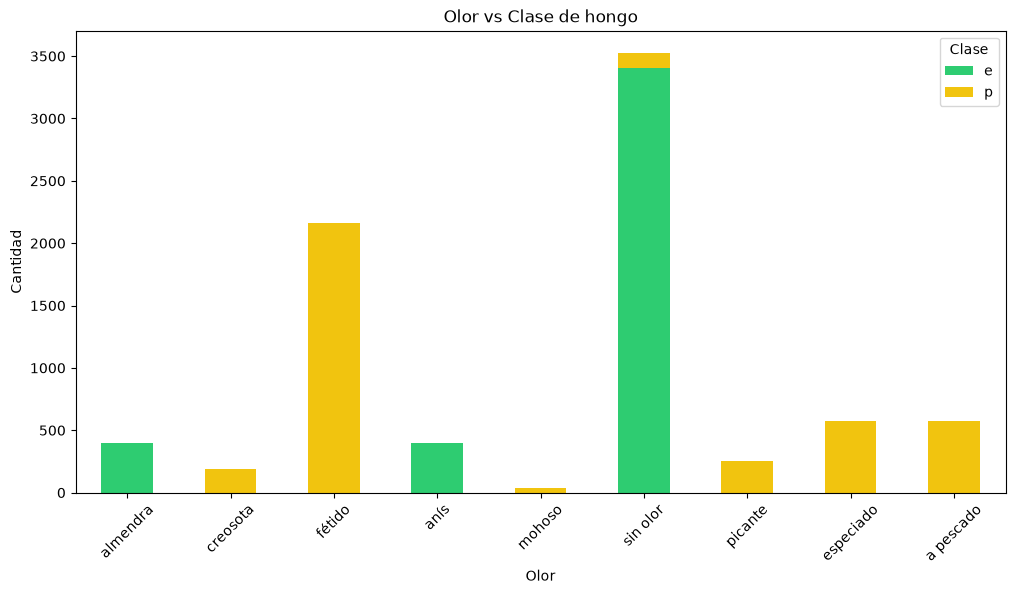

In [81]:
odor_map = {
    "a": "almendra",
    "l": "anís",
    "c": "creosota",
    "y": "a pescado",
    "f": "fétido",
    "m": "mohoso",
    "n": "sin olor",
    "p": "picante",
    "s": "especiado"
}
tabla = pd.crosstab(df["odor"], df["class"])
tabla.index = tabla.index.map(odor_map)
ax = tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#2ecc71", "#f1c40f"]
)
ax.set_xlabel("Olor")
ax.set_ylabel("Cantidad")
plt.title("Olor vs Clase de hongo")
plt.xticks(rotation=45)
plt.legend(title="Clase")
plt.show()



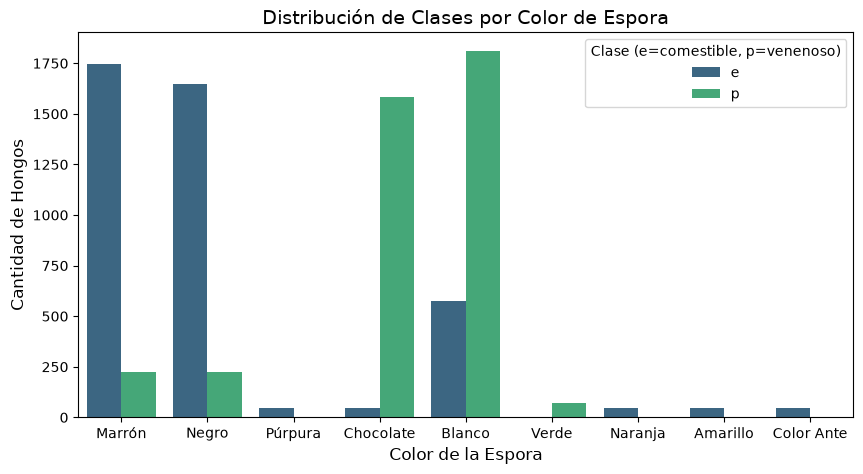

In [82]:
# Diccionario de traducción para los colores de la espora (eje X)
traduccion_espora = {
    'k': 'Negro', 'n': 'Marrón', 'b': 'Color Ante', 'h': 'Chocolate',
    'r': 'Verde', 'o': 'Naranja', 'u': 'Púrpura', 'w': 'Blanco', 'y': 'Amarillo'
}

plt.figure(figsize=(10, 5))

# Pasamos la traducción directa al eje X sin modificar el DataFrame
sns.countplot(x=df['spore-print-color'].map(traduccion_espora), hue=df['class'], palette='viridis')

# Traducimos los títulos de ambos ejes y el gráfico al español
plt.xlabel('Color de la Espora', fontsize=12)
plt.ylabel('Cantidad de Hongos', fontsize=12)
plt.title('Distribución de Clases por Color de Espora', fontsize=14)
plt.legend(title='Clase (e=comestible, p=venenoso)')

plt.show()

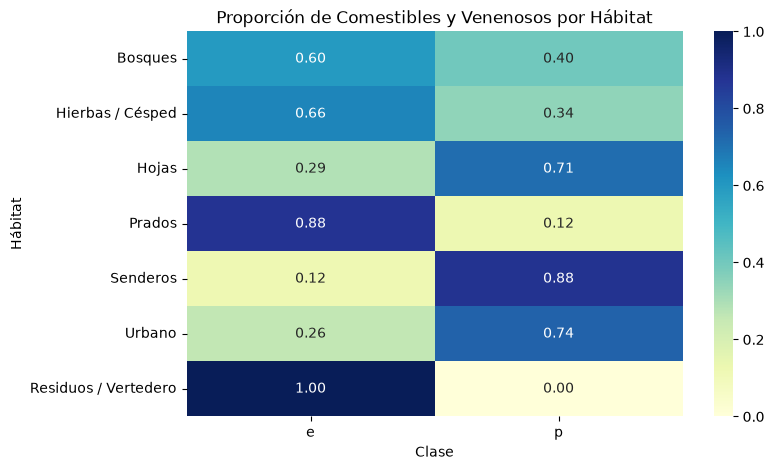

In [83]:
traduccion_habitat = {
    'g': 'Hierbas / Césped', 'l': 'Hojas', 'm': 'Prados',
    'p': 'Senderos', 'u': 'Urbano', 'w': 'Residuos / Vertedero', 'd': 'Bosques'
}

# Creamos la tabla normal
tabla = pd.crosstab(df['habitat'], df['class'], normalize='index')

# Renombramos las filas de la tabla usando el diccionario
tabla.index = tabla.index.map(traduccion_habitat)

# Graficamos el mapa de calor
plt.figure(figsize=(8, 5))
sns.heatmap(tabla, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title('Proporción de Comestibles y Venenosos por Hábitat')
plt.ylabel('Hábitat')
plt.xlabel('Clase')
plt.show()

Te dirá de forma muy visual si los hongos que crecen en determinados lugares (ej. senderos vs. bosques) o de cierta forma (ej. solitarios vs. numerosos) tienden a ser venenosos.

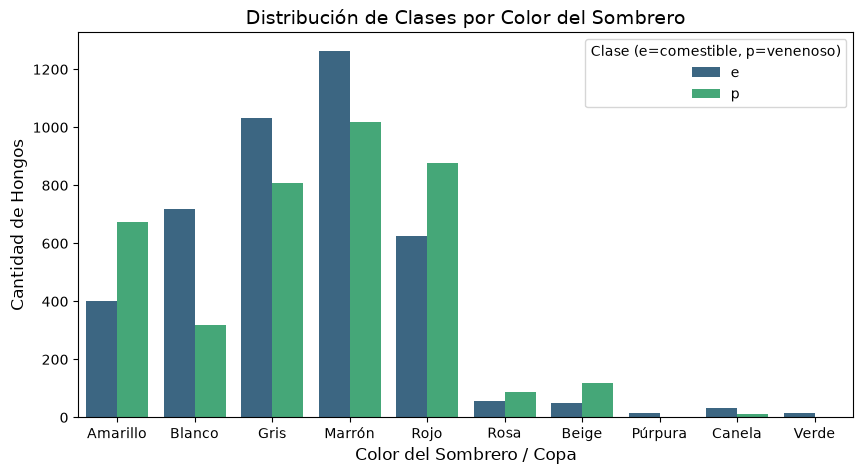

In [84]:
# Diccionario de traducción para los colores del sombrero/copa (eje X)
traduccion_copa = {
    'n': 'Marrón', 'b': 'Beige', 'c': 'Canela', 'g': 'Gris',
    'r': 'Verde', 'p': 'Rosa', 'u': 'Púrpura', 'e': 'Rojo',
    'w': 'Blanco', 'y': 'Amarillo'
}

plt.figure(figsize=(10, 5))

# Pasamos la traducción directa al eje X sin modificar el DataFrame
sns.countplot(x=df['cap-color'].map(traduccion_copa), hue=df['class'], palette='viridis')

# Traducimos los títulos de ambos ejes y el gráfico al español
plt.xlabel('Color del Sombrero / Copa', fontsize=12)
plt.ylabel('Cantidad de Hongos', fontsize=12)
plt.title('Distribución de Clases por Color del Sombrero', fontsize=14)
plt.legend(title='Clase (e=comestible, p=venenoso)')

plt.show()

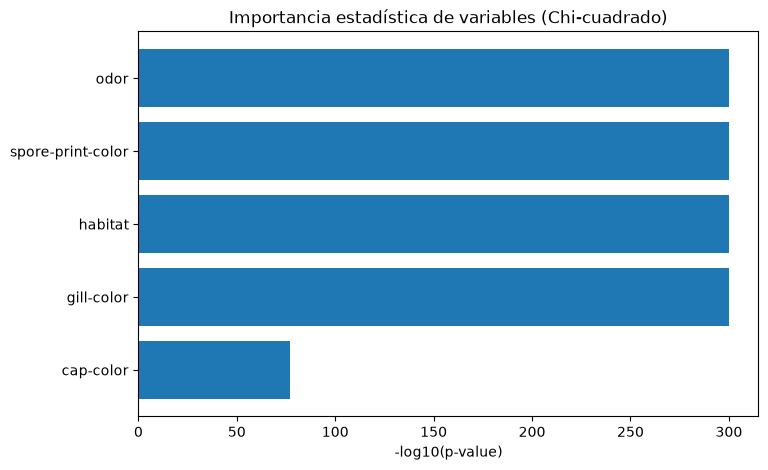

            variable       p_value       log_p
0               odor  0.000000e+00  300.000000
1  spore-print-color  0.000000e+00  300.000000
2            habitat  0.000000e+00  300.000000
4         gill-color  0.000000e+00  300.000000
3          cap-color  5.609094e-78   77.251107


In [85]:
# Test chi-cuadrado para medir relación entre variables categóricas y la clase

def chi_square_test(df, col, target='class'):
    # Tabla de contingencia entre variable y target
    tabla = pd.crosstab(df[col], df[target])
    
    # Cálculo del test chi-cuadrado
    _, p, _, _ = chi2_contingency(tabla)
    
    # Se devuelve solo el p-value
    return p


# Variables categóricas más relevantes del dataset
variables = [
    'odor',
    'spore-print-color',
    'habitat',
    'cap-color',
    'gill-color'
]

# Cálculo del p-value para cada variable
results = pd.DataFrame({
    "variable": variables,
    "p_value": [chi_square_test(df, col) for col in variables]
})

# Ordenamos de menor a mayor p-value (más significativas primero)
results = results.sort_values("p_value")

# Transformación logarítmica para visualización (-log10)
results["log_p"] = -np.log10(results["p_value"].replace(0, 1e-300))

# Gráfico de importancia estadística
plt.figure(figsize=(8,5))
plt.barh(results["variable"], results["log_p"])
plt.xlabel("-log10(p-value)")
plt.title("Importancia estadística de variables (Chi-cuadrado)")
plt.gca().invert_yaxis()
plt.show()

# Resultado final en tabla
print(results)

Se ha aplicado el test chi-cuadrado para ver qué variables están relacionadas con si un hongo es comestible o venenoso.

Los resultados muestran que casi todas las variables tienen un p-value cercano a 0, lo que indica una relación muy fuerte con la clase del hongo. Especialmente destacan odor, spore-print-color, habitat y gill-color.

En cambio, cap-color también está relacionado, pero de forma más débil.

En resumen, hay varias características muy útiles para predecir si un hongo es venenoso o no, siendo el olor la más importante.

In [86]:
# Crear carpeta data si no existe
data_dir = BASE_DIR / "data"
data_dir.mkdir(exist_ok=True)
# Guardar dataset limpio
clean_data_path = data_dir / "mushrooms_clean.csv"
df.to_csv(clean_data_path, index=False)
print(f"Dataset guardado en: {clean_data_path}")

Dataset guardado en: C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-project-classification-Grupo-1\data\mushrooms_clean.csv
